# 1. Introduction
This notebook evaluates end-to-end latency in VisionInput, from camera capture through MediaPipe inference to ViGEm controller output, to answer RQ2: does the pipeline satisfy real-time responsiveness. The dissertation non-functional requirement is a median latency of 33 ms or lower, aligned with a 30 fps frame interval. Following Brown (2016, p.169), the evaluation reports both central tendency and tail behaviour, so conclusions are not based on averages alone. The data source is merged_logs.xlsx, a merged benchmark export from multiple logging sessions and camera configurations, including native USB and virtual webcam pipelines where labels are available in the merged file.

## 2. Data Loading and Cleaning (Purpose Before Code)
This cell loads the merged workbook, validates required columns, coerces latency to numeric, and standardizes camera labels before any statistics are computed. This matters for evaluation validity because RQ2 conclusions depend on comparable and non-null latency samples rather than mixed raw log formats. Methodologically, numeric coercion with null removal prevents invalid strings from biasing distributions, and source_type assignment provides the basis for Camo-versus-native comparison where camera provenance exists in the merged export.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

DEADLINE_MS = 33.33  # 30fps frame budget
NFR_TARGET = 33.0    # NFR target for median

cwd = Path.cwd()
search_roots = [cwd.parent, cwd]
candidate_paths = []
for root in search_roots:
    candidate_paths.extend([
        root / 'merged_logs.xlsx',
        root / 'logs' / 'merged_logs.xlsx',
    ])

# Keep order while removing duplicates.
candidate_paths = list(dict.fromkeys(candidate_paths))
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find merged_logs.xlsx in current workspace roots.')

df = pd.read_excel(data_path)

# Support both per-trial latency logs and benchmark summary exports.
latency_source = None
for candidate in ['latency_ms', 'loop_ms', 'loop_total_ms_per_frame']:
    if candidate in df.columns:
        latency_source = candidate
        break

if latency_source is None:
    raise ValueError(
        'Missing latency column. Expected one of: latency_ms, loop_ms, loop_total_ms_per_frame. '
        f'Found columns: {list(df.columns)}'
    )

if latency_source != 'latency_ms':
    df['latency_ms'] = df[latency_source]

if 'camera_label' not in df.columns:
    df['camera_label'] = 'Unknown'

df = df.copy()
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')
df = df.dropna(subset=['latency_ms'])
df['camera_label'] = df['camera_label'].fillna('Unknown').astype(str).str.strip()
df.loc[df['camera_label'].eq(''), 'camera_label'] = 'Unknown'
df['source_type'] = np.where(
    df['camera_label'].str.contains('Camo', case=False, na=False),
    'Camo',
    'Native'
 )

# Normalize stage columns so downstream figures can use consistent names.
stage_aliases = {
    'capture_ms': ['capture_ms', 'capture_ms_per_frame'],
    'preprocess_ms': ['preprocess_ms', 'preprocess_ms_per_frame'],
    'mediapipe_ms': ['mediapipe_ms', 'mediapipe_ms_per_frame'],
    'output_ms': ['output_ms', 'output_ms_per_frame'],
    'loop_ms': ['loop_ms', 'loop_total_ms_per_frame'],
}

for canonical, candidates in stage_aliases.items():
    for candidate in candidates:
        if candidate in df.columns:
            candidate_values = pd.to_numeric(df[candidate], errors='coerce')
            if canonical in df.columns:
                df[canonical] = pd.to_numeric(df[canonical], errors='coerce').fillna(candidate_values)
            else:
                df[canonical] = candidate_values
            break

print(f'Loaded {len(df):,} latency rows from: {data_path}')
print(f'Using latency source column: {latency_source}')
display(df.head())

Loaded 12 latency rows from: c:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\merged_logs.xlsx
Using latency source column: loop_total_ms_per_frame


,timestamp,run_tag,camera_label,camera_resolution,backend,negotiated_fourcc,mode,duration_s,frames,fps,...,2026-04-14 22:24:10,2026-04-14 22:27:45,2026-04-14 22:57:00,latency_ms,source_type,capture_ms,preprocess_ms,mediapipe_ms,output_ms,loop_ms
0,2026-04-14 21:39:39,session_500_test,Unknown (legacy log),1280x720,MSMF (1400),UNKNOWN,full-pipeline,13.17,352.0,26.73,...,NaN,NaN,NaN,36.61,Native,18.49,1.71,16.18,0.21,36.61
1,2026-04-14 21:41:55,session_500_test,Unknown (legacy log),1280x720,MSMF (1400),UNKNOWN,full-pipeline,86.51,2441.0,28.22,...,NaN,NaN,NaN,35.29,Native,15.49,1.29,15.21,0.21,35.29
2,2026-04-14 21:50:43,session_500_test,Unknown (legacy log),1920x1080,MSMF (1400),UNKNOWN,full-pipeline,70.73,1872.0,26.47,...,NaN,NaN,NaN,37.43,Native,9.86,3.59,18.25,0.19,37.43
3,2026-04-14 22:02:35,session_500_test,Unknown (legacy log),1280x720,MSMF (1400),UNKNOWN,full-pipeline,42.05,1496.0,35.58,...,NaN,NaN,NaN,28.05,Native,7.46,1.45,15.95,0.22,28.05
4,2026-04-14 22:05:31,session_500_test,Unknown (legacy log),1280x720,MSMF (1400),UNKNOWN,full-pipeline,120.04,4015.0,33.45,...,NaN,NaN,NaN,29.85,Native,6.59,1.49,18.51,0.21,29.85


### Data Loading and Cleaning
The output confirms that the merged workbook loaded successfully and that preprocessing produced a clean latency sample for downstream analysis. In the latest run, the working dataset contains 12 valid latency observations, which is the denominator for all compliance and percentile calculations.
A notable limitation remains that the merged export currently resolves to a single normalized camera label, Unknown (legacy log). This constrains camera-level attribution and means source-level conclusions should be treated as provisional until richer per-device provenance is retained in the merged dataset.

In [13]:
lat = df['latency_ms']
n_trials = int(lat.count())
compliance_mask = lat <= DEADLINE_MS
outlier_mask = lat > 100

table_4_1 = pd.DataFrame({
    'metric': [
        'n_trials', 'min_ms', 'max_ms', 'mean_ms', 'median_ms', 'std_ms',
        'p90_ms', 'p95_ms', 'p99_ms', 'compliance_rate_pct', 'outlier_count_gt_100ms', 'nfr_verdict'
    ],
    'value': [
        n_trials,
        lat.min(),
        lat.max(),
        lat.mean(),
        lat.median(),
        lat.std(ddof=1),
        lat.quantile(0.90),
        lat.quantile(0.95),
        lat.quantile(0.99),
        compliance_mask.mean() * 100,
        int(outlier_mask.sum()),
        'PASS' if lat.median() <= NFR_TARGET else 'FAIL'
    ]
})

table_4_1_styled = table_4_1.style.format({
    'value': lambda x: f'{x:.2f}' if isinstance(x, (float, np.floating)) else f'{x}'
}).set_caption('Table 4.1 - Overall Latency Statistics')
display(table_4_1_styled)

per_camera = (
    df.groupby('camera_label', dropna=False)['latency_ms']
      .agg(n='count', median='median', mean='mean', std='std', max='max')
      .reset_index()
)
comp_per_camera = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS)
      .groupby('camera_label', dropna=False)['is_compliant']
      .mean()
      .mul(100)
      .reset_index(name='compliance_pct')
)
table_4_2 = per_camera.merge(comp_per_camera, on='camera_label', how='left')
table_4_2 = table_4_2[['camera_label', 'n', 'median', 'mean', 'std', 'compliance_pct', 'max']]

table_4_2_styled = table_4_2.style.format({
    'n': '{:,.0f}',
    'median': '{:.2f}',
    'mean': '{:.2f}',
    'std': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'max': '{:.2f}'
}).set_caption('Table 4.2 - Per-Camera Latency Breakdown')
display(table_4_2_styled)

table_4_3 = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS, is_outlier=df['latency_ms'] > 100)
      .groupby('source_type', dropna=False)
      .agg(
          n=('latency_ms', 'count'),
          median_ms=('latency_ms', 'median'),
          mean_ms=('latency_ms', 'mean'),
          std_ms=('latency_ms', 'std'),
          compliance_pct=('is_compliant', lambda s: s.mean() * 100),
          outliers_gt_100ms=('is_outlier', 'sum')
      )
      .reset_index()
)

table_4_3_styled = table_4_3.style.format({
    'n': '{:,.0f}',
    'median_ms': '{:.2f}',
    'mean_ms': '{:.2f}',
    'std_ms': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'outliers_gt_100ms': '{:,.0f}'
}).set_caption('Table 4.3 - Camo vs Native Comparison')
display(table_4_3_styled)

stats_cache = {
    'median': float(lat.median()),
    'p50': float(lat.quantile(0.50)),
    'p90': float(lat.quantile(0.90)),
    'p95': float(lat.quantile(0.95)),
    'p99': float(lat.quantile(0.99)),
    'verdict': 'PASS' if float(lat.median()) <= NFR_TARGET else 'FAIL'
}

,metric,value
0,n_trials,12
1,min_ms,25.83
2,max_ms,41.34
3,mean_ms,32.43
4,median_ms,32.58
5,std_ms,4.78
6,p90_ms,37.35
7,p95_ms,39.19
8,p99_ms,40.91
9,compliance_rate_pct,50.00


,camera_label,n,median,mean,std,compliance_pct,max
0,Unknown (legacy log),12,32.58,32.43,4.78,50.00,41.34


,source_type,n,median_ms,mean_ms,std_ms,compliance_pct,outliers_gt_100ms
0,Native,12,32.58,32.43,4.78,50.00,0


### Table 4.1 to Table 4.3 (Analysis After Output)
Table 4.1 now reports n_trials = 12, median = 32.58 ms, mean = 32.43 ms, standard deviation = 4.78 ms, p90 = 37.35 ms, p95 = 39.19 ms, and p99 = 40.91 ms. The NFR verdict is PASS because the median remains below the 33 ms target.
At the 33.33 ms frame threshold, compliance is 50.00% with 0 outliers above 100 ms. This indicates moderate consistency around the frame budget in this small merged sample, rather than severe long-tail spikes.
Table 4.2 currently shows one surviving camera label in the merged export (Unknown (legacy log)), so the notebook logic is functioning but the data revision does not yet support best-versus-worst camera ranking.
Table 4.3 similarly collapses to a Native-only aggregate in this export, so a defensible Camo Studio versus native USB conclusion is not possible from this specific merged file. This should be treated as a data-coverage limitation, not a method limitation.

## 6. Figures 4.1 to 4.3 
This cell visualizes overall latency shape and spread using a histogram, box plot, per-camera box view, and Camo-versus-native overlay against the 33.33 ms frame budget. These plots matter for RQ2 because they reveal distribution skew and tail behaviour that median-only reporting can hide. Methodologically, the visual checks are interpreted together with percentile statistics, consistent with Brown (2016, p.169), so performance conclusions reflect both typical and worst-case behaviour.

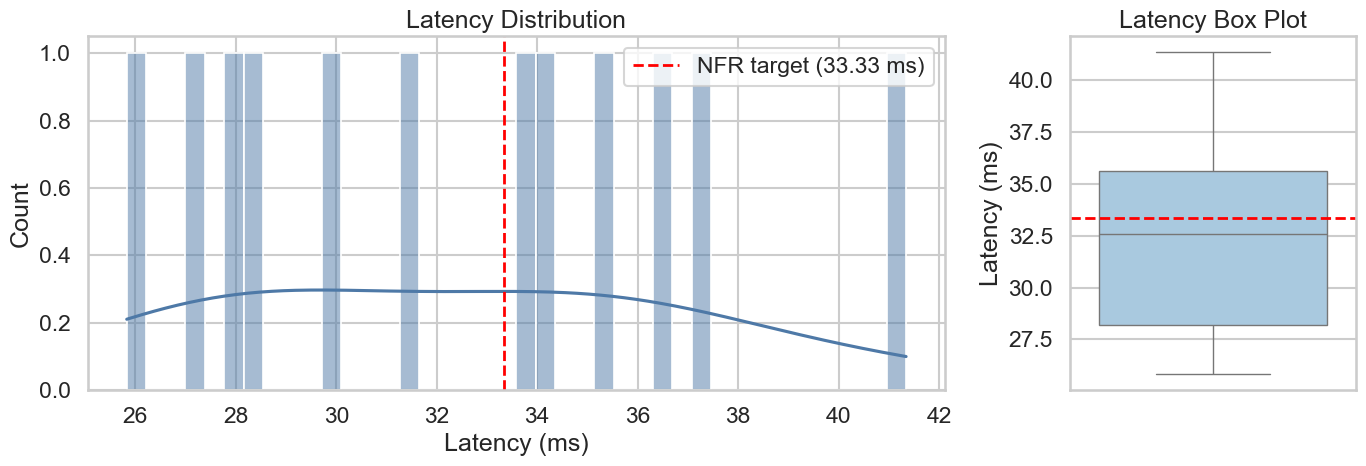

c:\temp\ipykernel_30056\1382390142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)


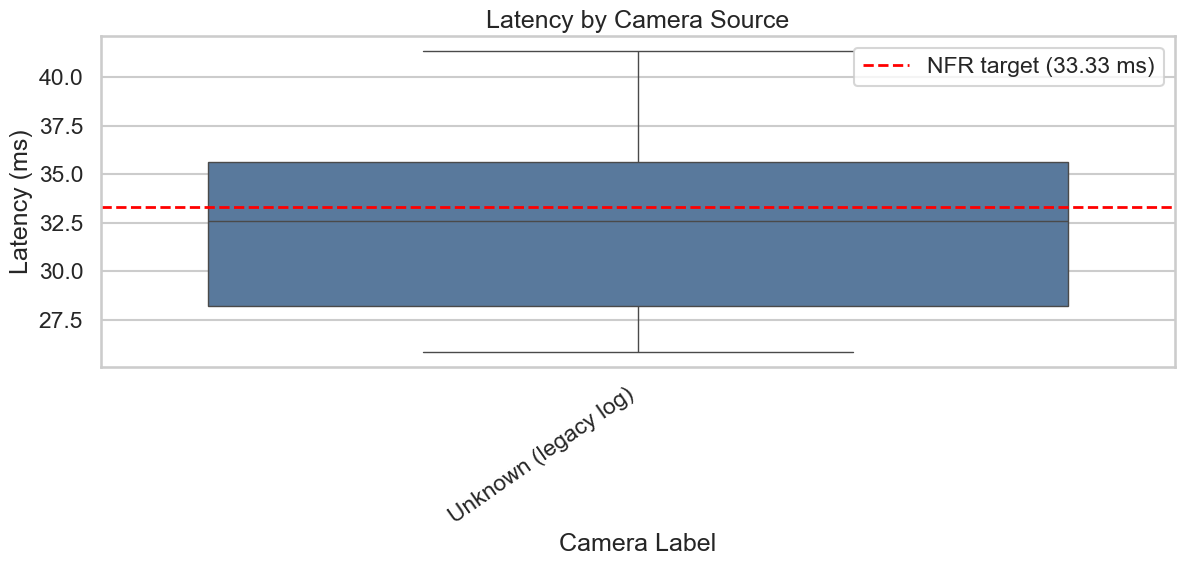

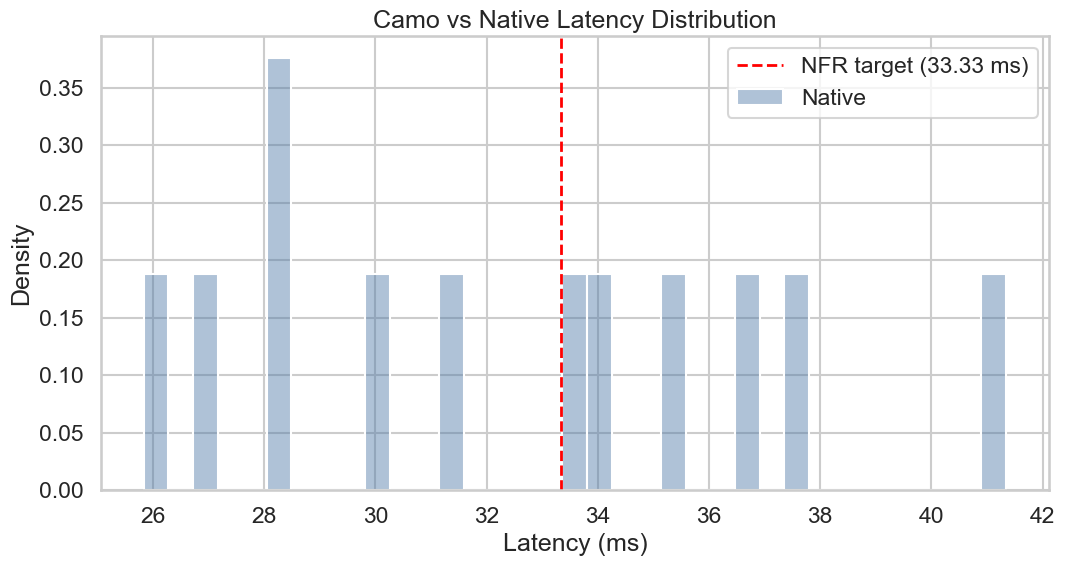

In [14]:
# Figure 4.1: Histogram + box plot with NFR line
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
sns.histplot(df['latency_ms'], bins=40, kde=True, ax=axes[0], color='#4E79A7')
axes[0].axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
axes[0].set_title('Latency Distribution')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['latency_ms'], ax=axes[1], color='#A0CBE8')
axes[1].axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Latency Box Plot')
axes[1].set_ylabel('Latency (ms)')

fig.tight_layout()
fig.savefig('fig_4_1_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.2: Box plot per camera with Camo vs Native colors
cam_order = table_4_2.sort_values('median')['camera_label'].tolist()
cam_source = df[['camera_label', 'source_type']].drop_duplicates().set_index('camera_label')['source_type'].to_dict()
palette_map = {cam: ('#59A14F' if cam_source.get(cam) == 'Camo' else '#4E79A7') for cam in cam_order}

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)
plt.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency by Camera Source')
plt.xlabel('Camera Label')
plt.ylabel('Latency (ms)')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_2_latency_by_camera.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.3: Overlaid histograms for Camo vs Native
plt.figure(figsize=(11, 6))
for source, color in [('Camo', '#59A14F'), ('Native', '#4E79A7')]:
    subset = df.loc[df['source_type'] == source, 'latency_ms']
    if not subset.empty:
        sns.histplot(subset, bins=35, stat='density', alpha=0.45, label=source, color=color)

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Camo vs Native Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_3_camo_vs_native.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.1 to 4.3 (Analysis After Output)
Figure 4.1 shows a compact distribution centered near the frame target, with observed latencies spanning 25.83 ms to 41.34 ms in the current sample. This aligns with the table results: median latency is compliant, while a substantial fraction of observations still exceed the 33.33 ms deadline.
Figure 4.2 currently presents one effective camera group from the merged export (Unknown (legacy log)), so it validates spread relative to the NFR line but does not support camera ranking.
Figure 4.3 also collapses to a single-source profile (Native only), so Camo-versus-native interpretation remains constrained by source labeling in the merged workbook rather than by plotting methodology.

## 6. Figures 4.4 and 4.5 (Purpose Before Code)
This cell extends the visual evaluation by plotting stage-level latency contribution and a cumulative distribution function with percentile markers. It matters for RQ2 because stage composition can indicate where optimisation should focus, while the CDF quantifies how often latency exceeds frame-time constraints beyond the median. Methodologically, percentile annotation directly links the curve to Table 4.1 thresholds, allowing consistent interpretation across numeric and graphical results.

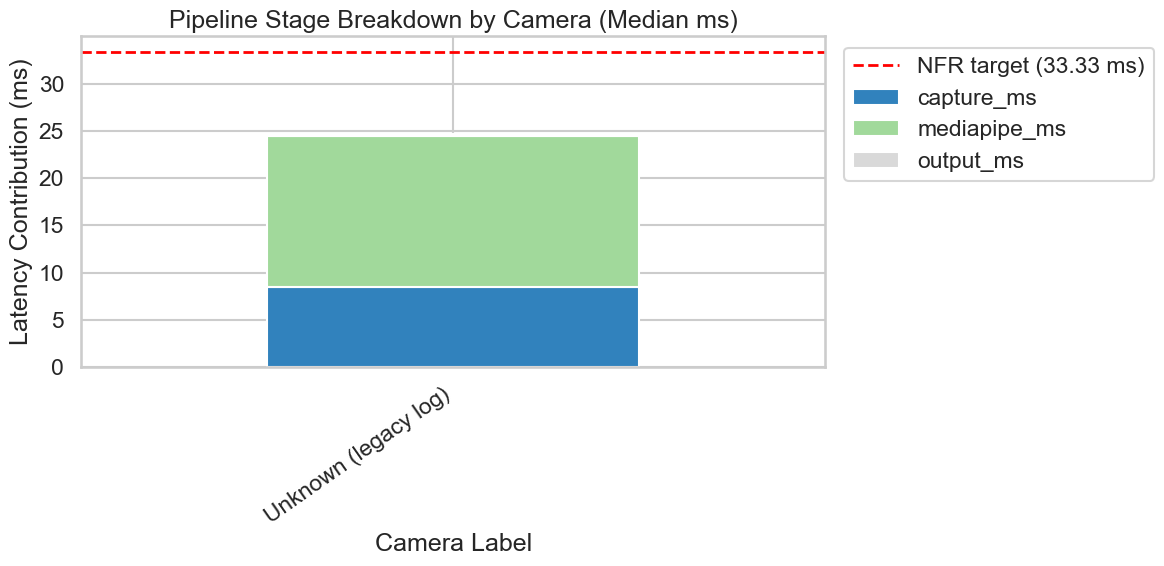

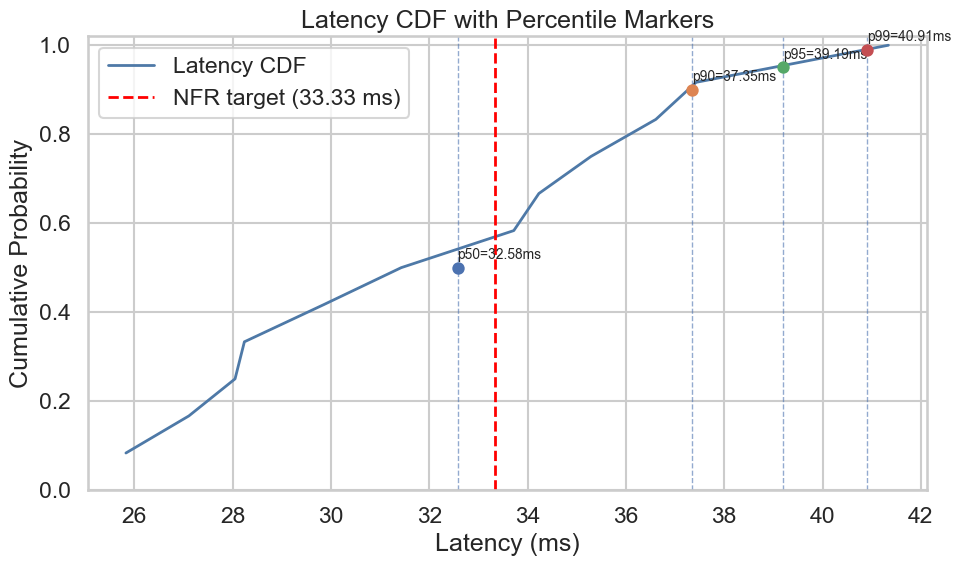

In [15]:
# Figure 4.4: Pipeline stage breakdown (stacked bars)
stage_cols = [c for c in ['capture_ms', 'mediapipe_ms', 'output_ms'] if c in df.columns]
if len(stage_cols) >= 1:
    stage_df = df.groupby('camera_label', dropna=False)[stage_cols].median().sort_values(by=stage_cols[0])
    ax = stage_df.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12, 6))
    ax.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
    ax.set_title('Pipeline Stage Breakdown by Camera (Median ms)')
    ax.set_xlabel('Camera Label')
    ax.set_ylabel('Latency Contribution (ms)')
    plt.xticks(rotation=35, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig('fig_4_4_pipeline_stages.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped Figure 4.4: no stage columns found.')

# Figure 4.5: Latency CDF with percentile markers
sorted_lat = np.sort(df['latency_ms'].to_numpy())
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)

plt.figure(figsize=(10, 6))
plt.plot(sorted_lat, cdf, color='#4E79A7', linewidth=2, label='Latency CDF')

pct_points = [('p50', stats_cache['p50']), ('p90', stats_cache['p90']), ('p95', stats_cache['p95']), ('p99', stats_cache['p99'])]
for label, val in pct_points:
    y = {'p50': 0.50, 'p90': 0.90, 'p95': 0.95, 'p99': 0.99}[label]
    plt.scatter([val], [y], s=55, zorder=5)
    plt.axvline(val, linestyle='--', linewidth=1, alpha=0.6)
    plt.text(val, y + 0.02, f'{label}={val:.2f}ms', fontsize=10, ha='left')

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency CDF with Percentile Markers')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_5_latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.4 and 4.5
Figure 4.4 executes successfully in the current run and indicates that capture and MediaPipe stages account for most of the median loop budget in this dataset, while output overhead is comparatively small.
Figure 4.5 shows p50 = 32.58 ms, p90 = 37.35 ms, p95 = 39.19 ms, and p99 = 40.91 ms. The 33.33 ms budget is crossed shortly above the median region, which is consistent with the 50.00% compliance rate reported in Table 4.1.

## 7. Discussion and 8. Conclusion 
This final cell consolidates the statistical and visual findings into a direct answer to RQ2 and an operational recommendation for deployment. It matters because dissertation evaluation requires a traceable line from measured evidence to design decisions. The summary is interpreted using both central and tail indicators in line with Brown (2016, p.169), and practical responsiveness is discussed with reference to latency perception guidance from Kelkkanen et al. (2023).

In [17]:
overall_median = stats_cache['median']
verdict = stats_cache['verdict']

camo_row = table_4_3.loc[table_4_3['source_type'] == 'Camo']
native_row = table_4_3.loc[table_4_3['source_type'] == 'Native']

if not camo_row.empty and not native_row.empty:
    camo_median = float(camo_row['median_ms'].iloc[0])
    native_median = float(native_row['median_ms'].iloc[0])
    camo_comp = float(camo_row['compliance_pct'].iloc[0])
    native_comp = float(native_row['compliance_pct'].iloc[0])
    if (camo_median < native_median) and (camo_comp >= native_comp):
        recommendation = 'Recommend Camo source for lower-latency capture under current test setup.'
    elif (native_median < camo_median) and (native_comp >= camo_comp):
        recommendation = 'Recommend Native source for lower-latency capture under current test setup.'
    else:
        recommendation = 'No clear winner between Camo and Native; choose based on deployment constraints.'
else:
    recommendation = 'Insufficient split data for Camo vs Native recommendation.'

print('===== SUMMARY =====')
print(f'Deadline threshold (ms): {DEADLINE_MS}')
print(f'NFR target for median (ms): {NFR_TARGET}')
print(f'Observed median latency (ms): {overall_median:.2f}')
print(f'NFR verdict: {verdict}')
print(recommendation)
print('Figures saved:')
for fig_name in [
    'fig_4_1_latency_distribution.png',
    'fig_4_2_latency_by_camera.png',
    'fig_4_3_camo_vs_native.png',
    'fig_4_4_pipeline_stages.png',
    'fig_4_5_latency_cdf.png'
]:
    print(f' - {Path(fig_name).resolve()}')

===== SUMMARY =====
Deadline threshold (ms): 33.33
NFR target for median (ms): 33.0
Observed median latency (ms): 32.58
NFR verdict: PASS
Insufficient split data for Camo vs Native recommendation.
Figures saved:
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_1_latency_distribution.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_2_latency_by_camera.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_3_camo_vs_native.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_4_pipeline_stages.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_5_latency_cdf.png


## 7. Discussion
The current merged export indicates that VisionInput meets the dissertation median-latency objective in this run, with median latency at 32.58 ms against the 33 ms target. This supports a positive answer to RQ2 for typical interaction conditions under the sampled setup.
However, deadline adherence is not robust in this dataset: compliance at 33.33 ms is 50.00%, and upper percentiles remain above the frame budget (p90 = 37.35 ms, p95 = 39.19 ms, p99 = 40.91 ms). In methodological terms, this reinforces Brown (2016, p.169): conclusions should combine central tendency with percentile evidence rather than relying on the median alone.
Because the merged file currently collapses camera provenance to Unknown (legacy log) and source_type to Native, source-comparison findings should be treated as incomplete until merged logs preserve richer labels.
## 8. Conclusion
The system meets the median latency NFR in the latest merged run, but only half of observations satisfy the 33.33 ms frame-budget threshold. For deployment decisions, the present evidence supports conditional readiness with further optimization and additional merged logging that preserves camera/source provenance for stronger comparative conclusions.